## Directionality Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

filepath = r"C:\Users\User\ACC Lab Dropbox\ACC Lab\Nicole Lee\Data Compilation\2025 Complete raw values osar falling\Falling_20260215.xlsx"
df = pd.read_excel(filepath)
metric_cols = [c for c in df.columns if c not in ['MBON', 'responder', 'genotypeandresponder']]
negligible_threshold = 0.2

selected_metrics = [ 'Fall number_\u0394\u0394', 'Average height climbed_\u0394g', 'Bout speed_\u0394g',
                    'Max velocity_\u0394g','Straightness Index_\u0394g', 'Duration of bouts_\u0394g','Number of Bouts_\u0394g'  ]  # if empty, use all; if populated, only these (use original column names)
if selected_metrics:
    metric_cols = [c for c in metric_cols if c in selected_metrics]

metric_display = {
    'Fall number_\u0394\u0394': 'Fall #',
    'Speed_\u0394g': 'Speed',
    'Average height climbed_\u0394g': 'Height',
    'Bout speed_\u0394g': 'Bout Speed',
    'Pause position_\u0394g': 'Pause Pos',
    'Max velocity_\u0394g': 'Max Velocity',
    'Straightness Index_\u0394g': 'Straightness',
    'Duration of bouts_\u0394g': 'Bout Time',
    'Number of Bouts_\u0394g': 'Bout #',
    'Log2 Bout Speed ratio_Hg': 'Log2 Bout Speed',
    'Log2 Speed ratio_Hg': 'Log2 Speed',
    'Bout Number index_Hg': 'Bout # Index',
    'Bout Duration ratio_Hg': 'Bout Duration',
    'Max Velocity ratio_Hg': 'Max Vel Ratio'
}

def classify(val):
    if abs(val) < negligible_threshold: return 0
    return 1 if val > 0 else -1

### Direction counts per responder

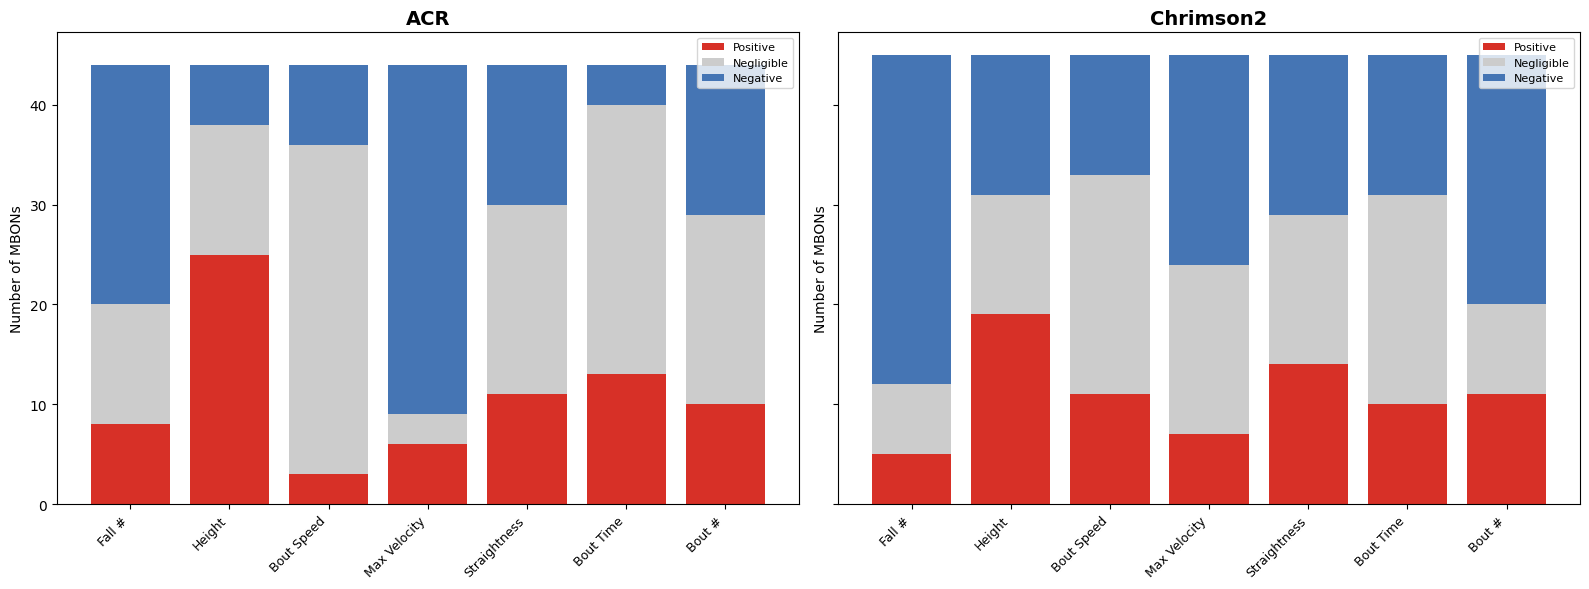

In [3]:
colors_dir = {1: '#d73027', 0: '#cccccc', -1: '#4575b4'}
labels_dir = {1: 'Positive', 0: 'Negligible', -1: 'Negative'}

responders = df['responder'].unique()
fig, axes = plt.subplots(1, len(responders), figsize=(8 * len(responders), 6), sharey=True)
if len(responders) == 1: axes = [axes]

for ax, resp in zip(axes, responders):
    subset = df[df['responder'] == resp]
    counts = {d: [] for d in [1, 0, -1]}
    display_names = []
    for metric in metric_cols:
        dirs = subset[metric].apply(classify)
        for d in [1, 0, -1]: counts[d].append((dirs == d).sum())
        display_names.append(metric_display.get(metric, metric))
    
    x = range(len(metric_cols))
    bottom = np.zeros(len(metric_cols))
    for d in [1, 0, -1]:
        ax.bar(x, counts[d], bottom=bottom, color=colors_dir[d], label=labels_dir[d])
        bottom += np.array(counts[d])
    
    ax.set_xticks(x)
    ax.set_xticklabels(display_names, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Number of MBONs')
    ax.set_title(resp, fontsize=14, fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Direction heatmap per MBON x metric

C:\Users\User\AppData\Local\Temp\ipykernel_20924\1518942435.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dir_df = subset.applymap(classify)


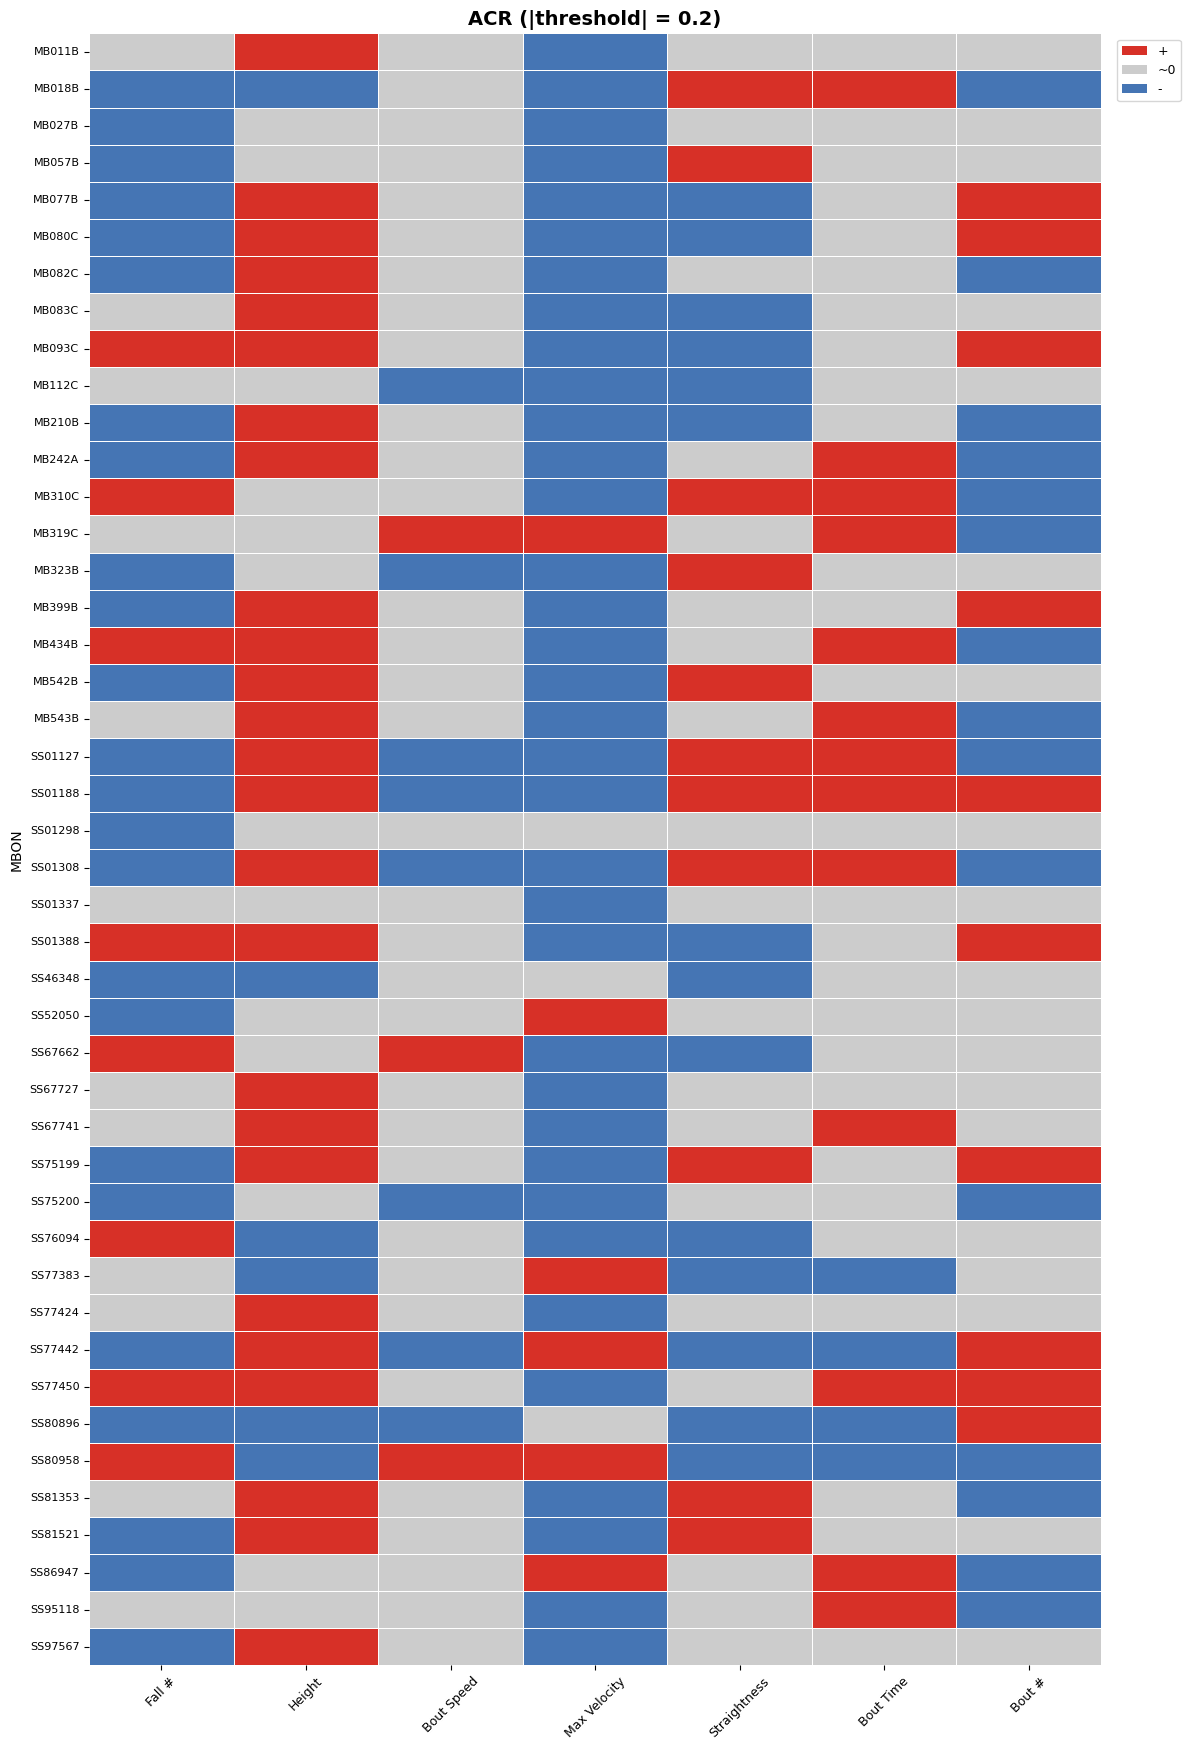

C:\Users\User\AppData\Local\Temp\ipykernel_20924\1518942435.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dir_df = subset.applymap(classify)


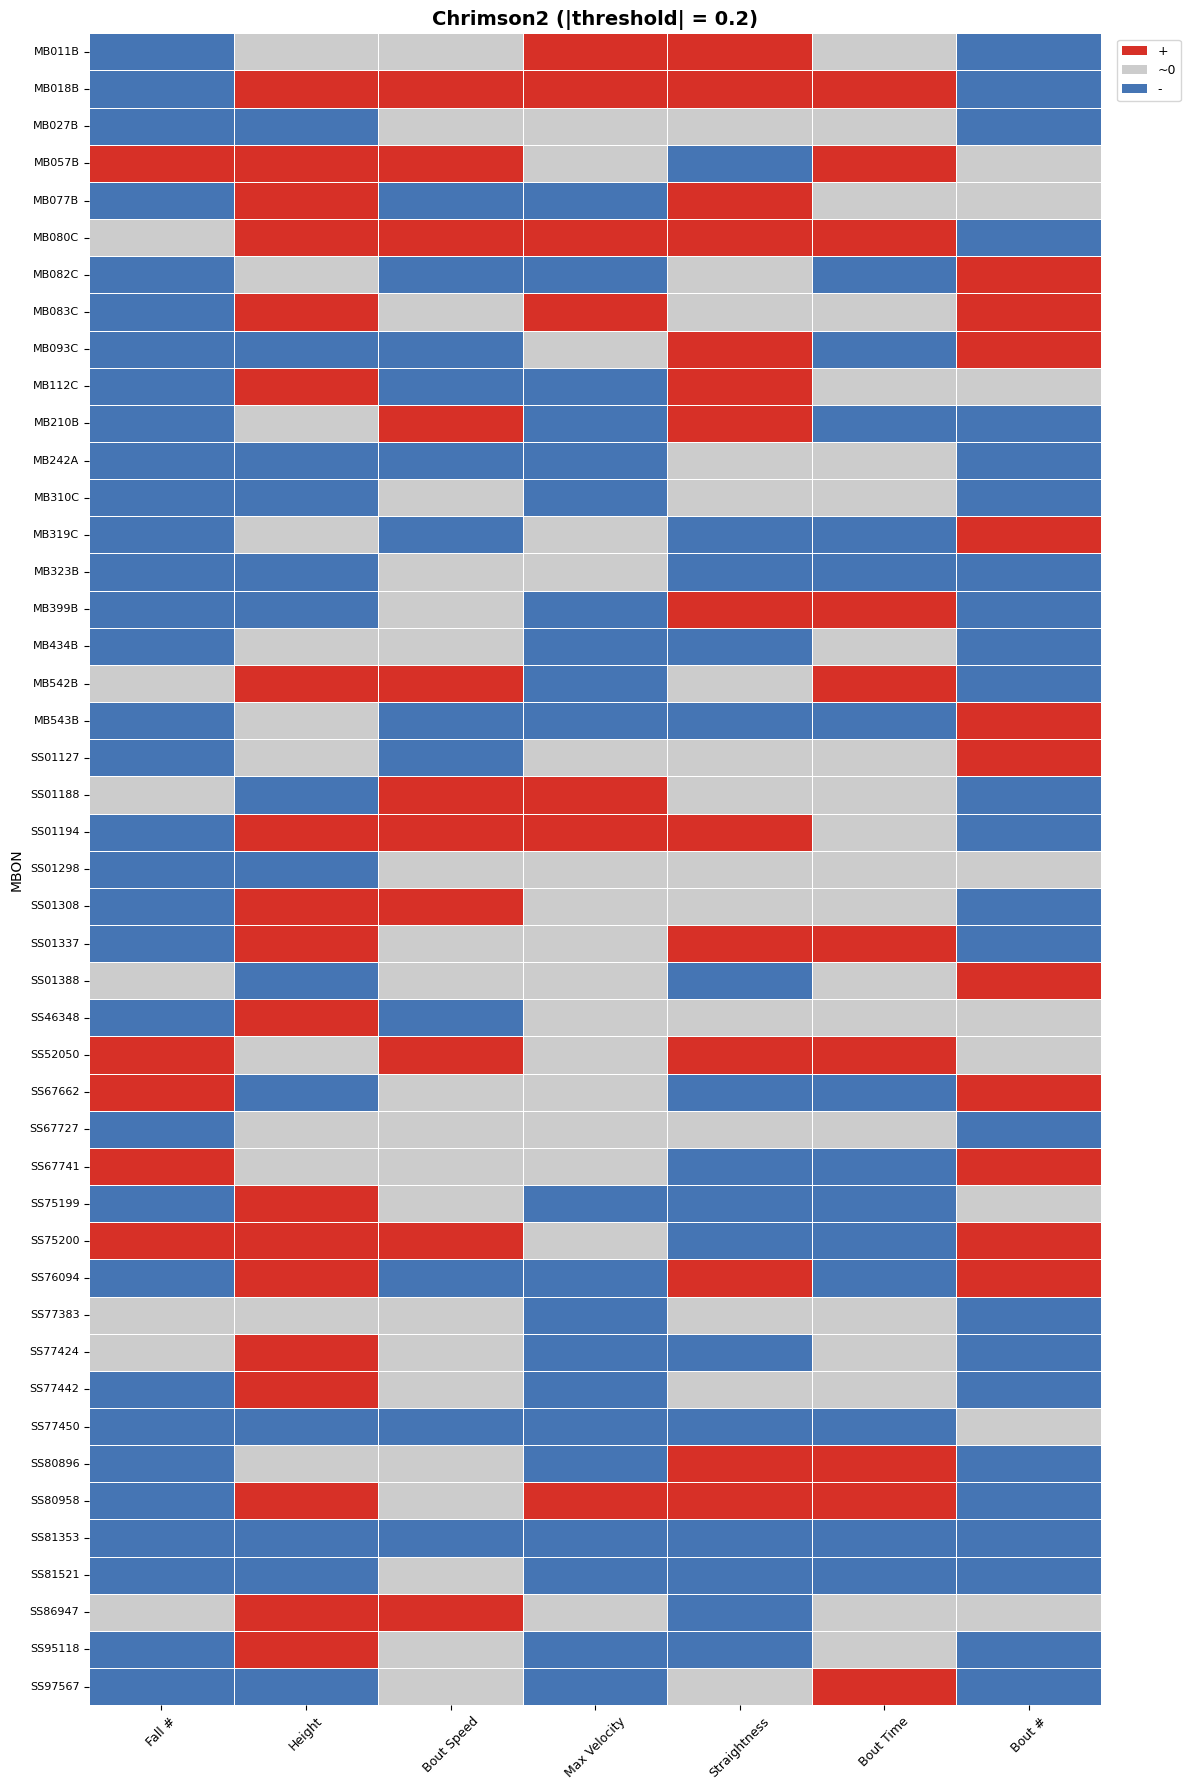

In [4]:
cmap_dir = plt.cm.colors.ListedColormap(['#4575b4', '#cccccc', '#d73027'])

for resp in responders:
    subset = df[df['responder'] == resp].set_index('MBON')[metric_cols]
    dir_df = subset.applymap(classify)
    dir_df.columns = [metric_display.get(c, c) for c in dir_df.columns]
    
    fig, ax = plt.subplots(figsize=(12, len(subset) * 0.4))
    sns.heatmap(dir_df, cmap=cmap_dir, center=0, vmin=-1.5, vmax=1.5,
                linewidths=0.5, linecolor='white', cbar=False, ax=ax)
    
    ax.legend(handles=[Patch(facecolor='#d73027', label='+'), Patch(facecolor='#cccccc', label='~0'),
                       Patch(facecolor='#4575b4', label='-')],
              loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9)
    ax.set_title(f'{resp} (|threshold| = {negligible_threshold})', fontsize=14, fontweight='bold')
    ax.tick_params(axis='y', labelsize=8)
    ax.tick_params(axis='x', labelsize=9, rotation=45)
    plt.tight_layout()
    plt.show()

### Agreement across responders

C:\Users\User\AppData\Local\Temp\ipykernel_20924\3469739530.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dir1 = df1.loc[common].applymap(classify)
C:\Users\User\AppData\Local\Temp\ipykernel_20924\3469739530.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dir2 = df2.loc[common].applymap(classify)


MBONs in both: 44
  Fall #                same=18  opposite=9  negligible=17
  Height                same=8  opposite=13  negligible=23
  Bout Speed            same=2  opposite=4  negligible=38
  Max Velocity          same=19  opposite=7  negligible=18
  Straightness          same=3  opposite=13  negligible=28
  Bout Time             same=1  opposite=6  negligible=37
  Bout #                same=11  opposite=10  negligible=23


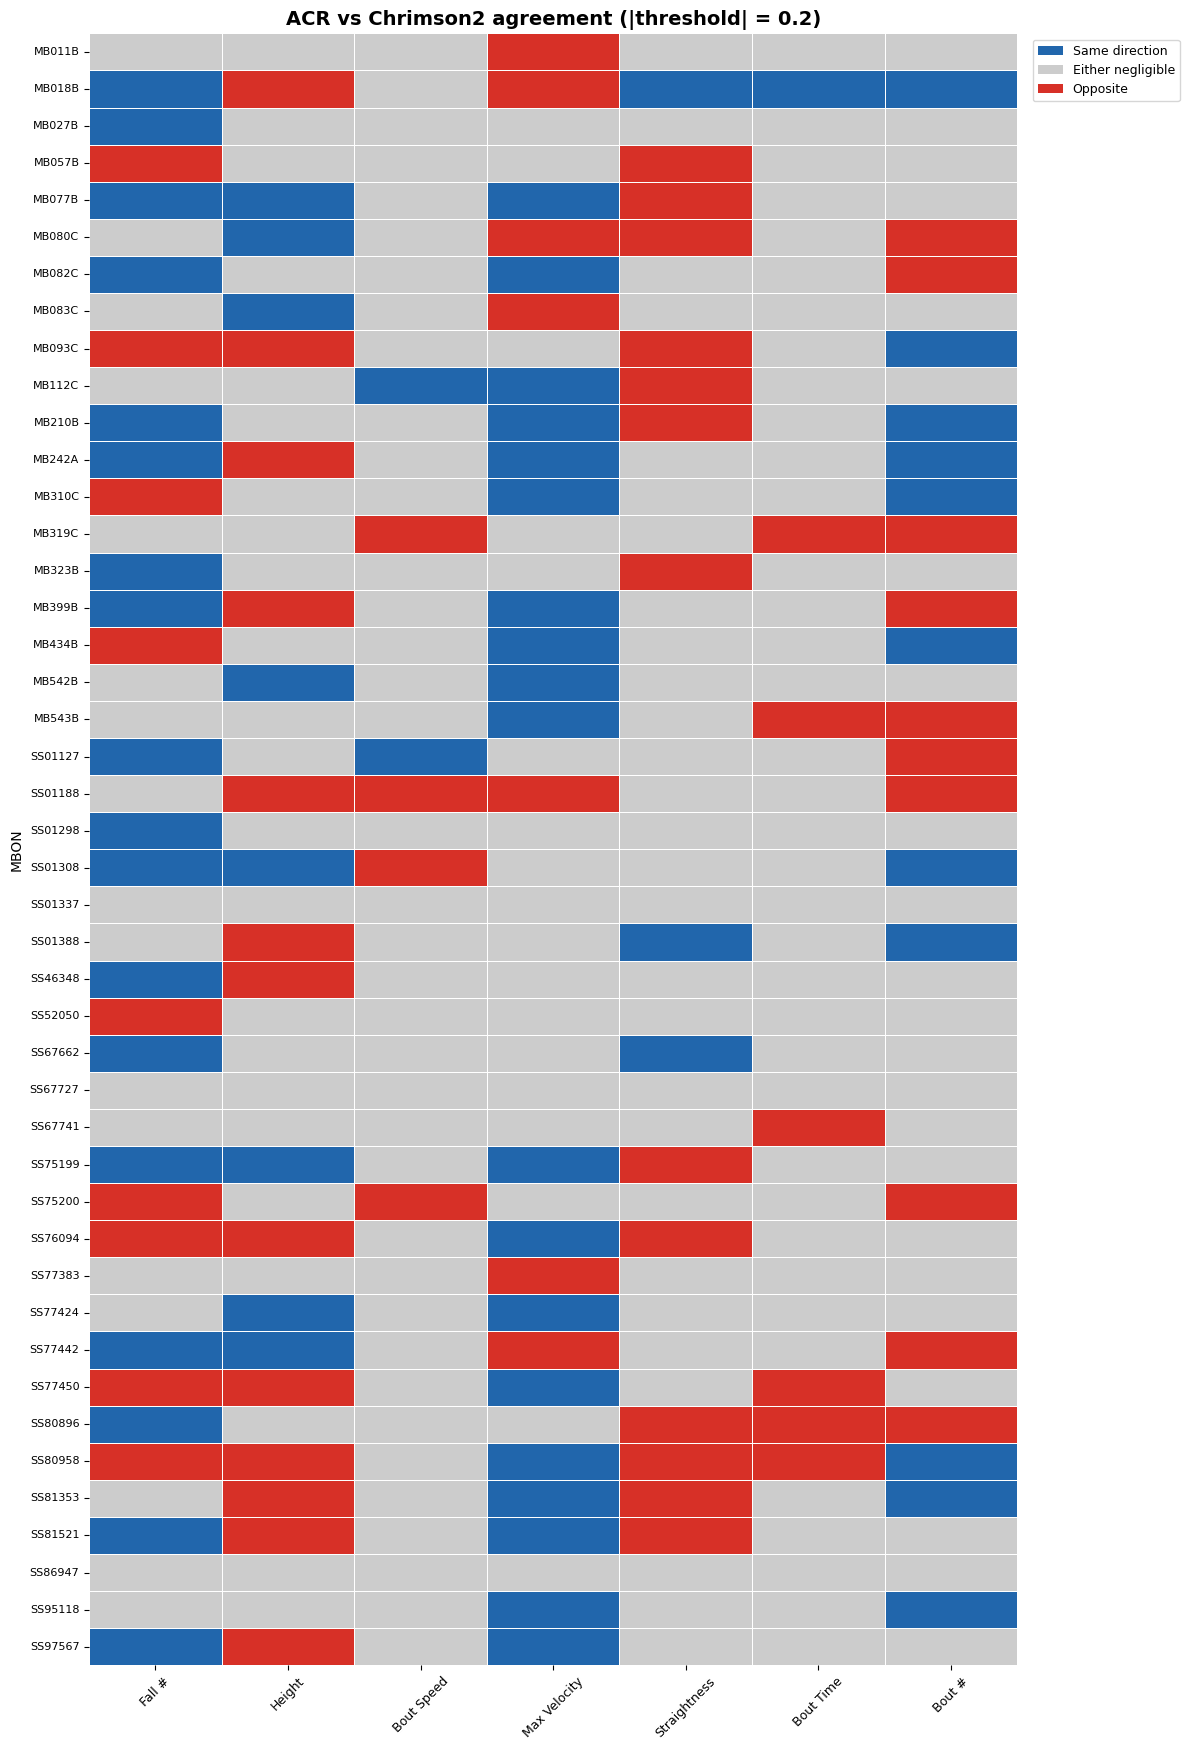

In [5]:
r1, r2 = responders[0], responders[1]
df1 = df[df['responder'] == r1].set_index('MBON')[metric_cols]
df2 = df[df['responder'] == r2].set_index('MBON')[metric_cols]
common = df1.index.intersection(df2.index)

dir1 = df1.loc[common].applymap(classify)
dir2 = df2.loc[common].applymap(classify)

agree_map = pd.DataFrame(0, index=common, columns=metric_cols)
agree_map[(dir1 == dir2) & (dir1 != 0)] = 1
agree_map[((dir1 == 1) & (dir2 == -1)) | ((dir1 == -1) & (dir2 == 1))] = -1
agree_map.columns = [metric_display.get(c, c) for c in agree_map.columns]

print(f"MBONs in both: {len(common)}")
for metric in agree_map.columns:
    same = (agree_map[metric] == 1).sum()
    opp = (agree_map[metric] == -1).sum()
    negl = (agree_map[metric] == 0).sum()
    print(f"  {metric:20s}  same={same}  opposite={opp}  negligible={negl}")

fig, ax = plt.subplots(figsize=(12, len(common) * 0.4))
cmap_agree = plt.cm.colors.ListedColormap(['#d73027', '#cccccc', '#2166ac'])
sns.heatmap(agree_map, cmap=cmap_agree, center=0, vmin=-1.5, vmax=1.5,
            linewidths=0.5, linecolor='white', cbar=False, ax=ax)
ax.legend(handles=[Patch(facecolor='#2166ac', label='Same direction'),
                   Patch(facecolor='#cccccc', label='Either negligible'),
                   Patch(facecolor='#d73027', label='Opposite')],
          loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9)
ax.set_title(f'{r1} vs {r2} agreement (|threshold| = {negligible_threshold})', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=8)
ax.tick_params(axis='x', labelsize=9, rotation=45)
plt.tight_layout()
plt.show()

### MBONs grouped by agreement level

In [6]:
all_dir = df.set_index('genotypeandresponder')[metric_cols].applymap(classify)
display_cols = [metric_display.get(c, c) for c in metric_cols]

pattern_groups = all_dir.groupby(list(metric_cols)).groups
pattern_groups = {k: list(v) for k, v in pattern_groups.items() if len(v) > 1}
pattern_groups = dict(sorted(pattern_groups.items(), key=lambda x: -len(x[1])))

for pattern, members in pattern_groups.items():
    dir_labels = {1: '+', 0: '~0', -1: '-'}
    pattern_str = ', '.join(f"{col}={dir_labels[d]}" for col, d in zip(display_cols, pattern))
    print(f"Group ({len(members)} members): [{pattern_str}]")
    for m in members:
        print(f"  {m}")
    print()

Group (3 members): [Fall #=~0, Height=+, Bout Speed=~0, Max Velocity=-, Straightness=~0, Bout Time=~0, Bout #=~0]
  MB011B_ACR
  SS67727_ACR
  SS77424_ACR

Group (2 members): [Fall #=-, Height=-, Bout Speed=~0, Max Velocity=-, Straightness=+, Bout Time=+, Bout #=-]
  MB018B_ACR
  MB399B_Chrimson2

Group (2 members): [Fall #=-, Height=+, Bout Speed=-, Max Velocity=-, Straightness=+, Bout Time=~0, Bout #=~0]
  MB077B_Chrimson2
  MB112C_Chrimson2

Group (2 members): [Fall #=-, Height=+, Bout Speed=-, Max Velocity=-, Straightness=+, Bout Time=+, Bout #=-]
  SS01127_ACR
  SS01308_ACR

Group (2 members): [Fall #=-, Height=+, Bout Speed=~0, Max Velocity=-, Straightness=-, Bout Time=~0, Bout #=-]
  MB210B_ACR
  SS95118_Chrimson2

Group (2 members): [Fall #=-, Height=+, Bout Speed=~0, Max Velocity=-, Straightness=-, Bout Time=~0, Bout #=+]
  MB077B_ACR
  MB080C_ACR

Group (2 members): [Fall #=-, Height=+, Bout Speed=~0, Max Velocity=-, Straightness=~0, Bout Time=~0, Bout #=-]
  MB082C_ACR
  SS7

C:\Users\User\AppData\Local\Temp\ipykernel_20924\3593541043.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  all_dir = df.set_index('genotypeandresponder')[metric_cols].applymap(classify)


Matching phenotype (Fall#=-, Height=+, Bout Speed=-, Max Vel=-, Straightness=+): 6

                      Fall #  Height  Bout Speed  Max Velocity  Straightness  Bout Time  Bout #
genotypeandresponder                                                                           
MB077B_Chrimson2      -3.970   0.597      -0.590        -1.039         0.514      0.141  -0.158
MB112C_Chrimson2      -2.497   0.285      -0.279        -0.379         0.257     -0.110   0.031
SS01127_ACR           -0.485   0.287      -0.313        -1.478         0.231      0.216  -0.507
SS01188_ACR           -2.812   0.924      -0.848        -0.904         0.701      0.819   0.386
SS01308_ACR           -2.958   0.359      -0.566        -1.131         1.858      0.809  -0.995
SS76094_Chrimson2     -0.938   0.348      -0.267        -0.367         0.252     -0.313   0.247


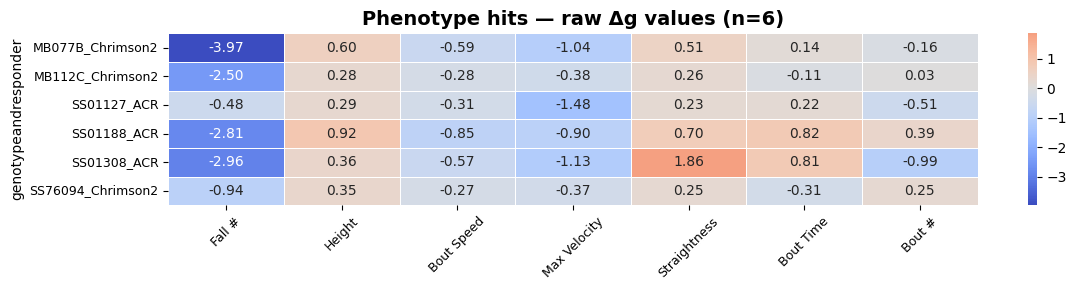

In [ ]:
phenotype = {
    'Fall number_ΔΔ': -1,
    'Average height climbed_Δg': 1,
    'Bout speed_Δg': -1,
    'Max velocity_Δg': -1,
    'Straightness Index_Δg': 1,
}

all_dir = df.set_index('genotypeandresponder')[metric_cols].map(classify)
mask = pd.Series(True, index=all_dir.index)
for col, direction in phenotype.items():
    mask &= (all_dir[col] == direction)

hit_names = all_dir.loc[mask].index
raw_hits = df.set_index('genotypeandresponder').loc[hit_names, metric_cols]
raw_hits.columns = [metric_display.get(c, c) for c in raw_hits.columns]

print(f"Matching phenotype (Fall#=-, Height=+, Bout Speed=-, Max Vel=-, Straightness=+): {len(raw_hits)}\n")
print(raw_hits.to_string())

fig, ax = plt.subplots(figsize=(12, max(len(raw_hits) * 0.5, 2)))
sns.heatmap(raw_hits, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_title(f'Phenotype hits (n={len(raw_hits)})', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=9)
ax.tick_params(axis='x', labelsize=9, rotation=45)
plt.tight_layout()
plt.show()